Simple Particle Filter

In [ ]:
import numpy as np
import statistics as stats

class DiagnosisSensor:
    """
    Binary diagnostic sensor
    """
    def __init__(self, sensor_reliability: float = 0.9):
        self.sensor_reliability = sensor_reliability

    def generate_evidence(self, true_state: int) -> int:
        if np.random.rand() < self.sensor_reliability:
            return true_state
        else:
            return 1 - true_state


class SimpleTTFParticleFilter:

    def __init__(
        self,
        true_ttf: float,
        diagnostic_sensors: list,
        n_particles: int = 500,
        ttf_prior_mean: float = 50.0,
        ttf_prior_std: float = 20.0,
    ):
        self.true_ttf = true_ttf
        self.sensors = diagnostic_sensors
        self.n = n_particles

        self.particles = np.clip(
            np.random.normal(ttf_prior_mean, ttf_prior_std, self.n),
            0.1,
            None
        )

        self.weights = np.ones(self.n) / self.n

    # -----------------------------------------------------
    def likelihood(self, evidence, t, ttf_particle):
        """
        Joint likelihood from multiple sensors
        """
        predicted_state = 1 if t < ttf_particle else 0

        likelihood = 1.0
        for z, sensor in zip(evidence, self.sensors):
            if z == predicted_state:
                likelihood *= sensor.sensor_reliability
            else:
                likelihood *= (1.0 - sensor.sensor_reliability)

        return likelihood

    # -----------------------------------------------------
    def resample(self):
        idx = np.random.choice(self.n, size=self.n, p=self.weights)
        self.particles = self.particles[idx]
        self.weights[:] = 1.0 / self.n

    # -----------------------------------------------------
    def step(self, t: float):

        true_state = 1 if t < self.true_ttf else 0

        # Generate evidence from all sensors
        z = [sensor.generate_evidence(true_state) for sensor in self.sensors]

        # Importance weighting
        for i in range(self.n):
            self.weights[i] *= self.likelihood(
                z, t, self.particles[i]
            )

        # Normalize
        self.weights += 1e-12
        self.weights /= np.sum(self.weights)

        # Resample if needed
        n_eff = 1.0 / np.sum(self.weights ** 2)
        if n_eff < 0.5 * self.n:
            self.resample()

        return z

    # -----------------------------------------------------
    def estimate_ttf(self):
        return np.sum(self.weights * self.particles)


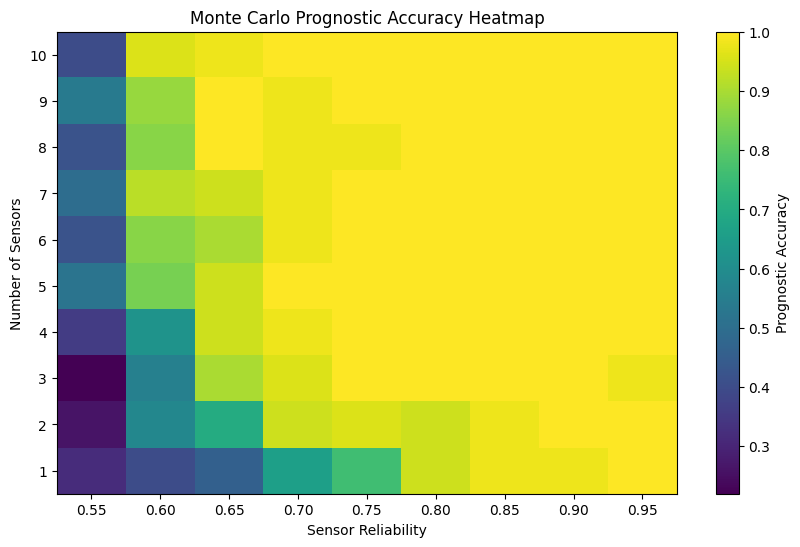

In [ ]:
import matplotlib.pyplot as plt

# --- Monte Carlo grid parameters ---
sensor_counts = np.arange(1, 11)          # 1 to 10 sensors
sensor_reliabilities = np.linspace(0.55, 0.95, 9)
N_mc = 50                                 # Monte Carlo runs per cell

true_ttf = 40.0
t_end = 80
dt = 1.0
t_array = np.arange(0, t_end, dt)

tolerance_frac = 0.1  # ±10% correctness threshold

accuracy_grid = np.zeros((len(sensor_counts), len(sensor_reliabilities)))

# --- Monte Carlo sweep ---
for i, n_sensors in enumerate(sensor_counts):
    for j, reliability in enumerate(sensor_reliabilities):

        correct = 0

        for _ in range(N_mc):
            sensors = [DiagnosisSensor(reliability) for _ in range(n_sensors)]
            pf = SimpleTTFParticleFilter(true_ttf, sensors)

            for t in t_array:
                pf.step(t)

            tf_est = pf.estimate_ttf()
            if abs(tf_est - true_ttf) <= tolerance_frac * true_ttf:
                correct += 1

        accuracy_grid[i, j] = correct / N_mc


# --- Heatmap visualization ---
plt.figure(figsize=(10, 6))
plt.imshow(
    accuracy_grid,
    origin="lower",
    aspect="auto"
)
plt.colorbar(label="Prognostic Accuracy")
plt.xticks(
    ticks=np.arange(len(sensor_reliabilities)),
    labels=[f"{r:.2f}" for r in sensor_reliabilities]
)
plt.yticks(
    ticks=np.arange(len(sensor_counts)),
    labels=sensor_counts
)
plt.xlabel("Sensor Reliability")
plt.ylabel("Number of Sensors")
plt.title("Monte Carlo Prognostic Accuracy Heatmap")
plt.show()

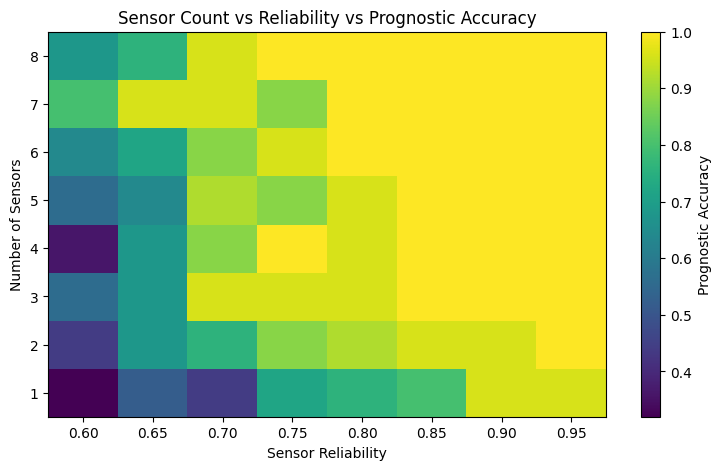

In [12]:
# Faster Monte Carlo simulation with reduced load
import numpy as np
import matplotlib.pyplot as plt

class DiagnosisSensor:
    def __init__(self, sensor_reliability: float):
        self.sensor_reliability = sensor_reliability

    def generate_evidence(self, true_state: int) -> int:
        if np.random.rand() < self.sensor_reliability:
            return true_state
        return 1 - true_state


class SimpleTTFParticleFilter:
    def __init__(self, true_ttf, sensors, n_particles=120):
        self.true_ttf = true_ttf
        self.sensors = sensors
        self.n = n_particles
        self.particles = np.clip(
            np.random.normal(true_ttf, 15.0, self.n), 0.1, None
        )
        self.weights = np.ones(self.n) / self.n

    def step(self, t):
        true_state = 1 if t < self.true_ttf else 0
        z = [s.generate_evidence(true_state) for s in self.sensors]

        for i in range(self.n):
            predicted_state = 1 if t < self.particles[i] else 0
            for obs, s in zip(z, self.sensors):
                if obs == predicted_state:
                    self.weights[i] *= s.sensor_reliability
                else:
                    self.weights[i] *= (1 - s.sensor_reliability)

        self.weights += 1e-12
        self.weights /= np.sum(self.weights)

        if 1.0 / np.sum(self.weights ** 2) < 0.5 * self.n:
            idx = np.random.choice(self.n, self.n, p=self.weights)
            self.particles = self.particles[idx]
            self.weights[:] = 1.0 / self.n

    def estimate(self):
        return np.sum(self.weights * self.particles)


# Grid parameters
sensor_counts = np.arange(1, 9)
sensor_reliabilities = np.linspace(0.6, 0.95, 8)
N_mc = 25

true_ttf = 40.0
t_array = np.arange(0, 70, 2)

accuracy = np.zeros((len(sensor_counts), len(sensor_reliabilities)))

for i, n_s in enumerate(sensor_counts):
    for j, r in enumerate(sensor_reliabilities):
        hits = 0
        for _ in range(N_mc):
            sensors = [DiagnosisSensor(r) for _ in range(n_s)]
            pf = SimpleTTFParticleFilter(true_ttf, sensors)

            # generate a set of weights of all the particles for each time step
            for t in t_array:
                pf.step(t)

            # consider the final estimated state of the pf at the end of all time step updates
            if abs(pf.estimate() - true_ttf) <= 0.1 * true_ttf:
                hits += 1

        accuracy[i, j] = hits / N_mc


# Heatmap
plt.figure(figsize=(9, 5))
plt.imshow(accuracy, origin="lower", aspect="auto")
plt.colorbar(label="Prognostic Accuracy")
plt.xticks(np.arange(len(sensor_reliabilities)),
           [f"{r:.2f}" for r in sensor_reliabilities])
plt.yticks(np.arange(len(sensor_counts)), sensor_counts)
plt.xlabel("Sensor Reliability")
plt.ylabel("Number of Sensors")
plt.title("Sensor Count vs Reliability vs Prognostic Accuracy")
plt.show()

In [11]:
# initialize n diagnostic sensors
num_sensors = 3
sensor_rel = 0.50
sensors = []
for i in range(num_sensors):
    sensors.append(DiagnosisSensor(sensor_rel))

# initialize a pf (prognosis sensor)
pf = SimpleTTFParticleFilter(
    true_ttf=40.0,
    diagnostic_sensors=sensors
)

times = np.arange(0, 80, 1)
estimates = []
evidence = []

for t in times:
    z = pf.step(t)
    evidence.append(z)
    estimates.append(pf.estimate_ttf())

print("Final TTF estimate:", estimates[-1])


TypeError: SimpleTTFParticleFilter.__init__() got an unexpected keyword argument 'diagnostic_sensors'

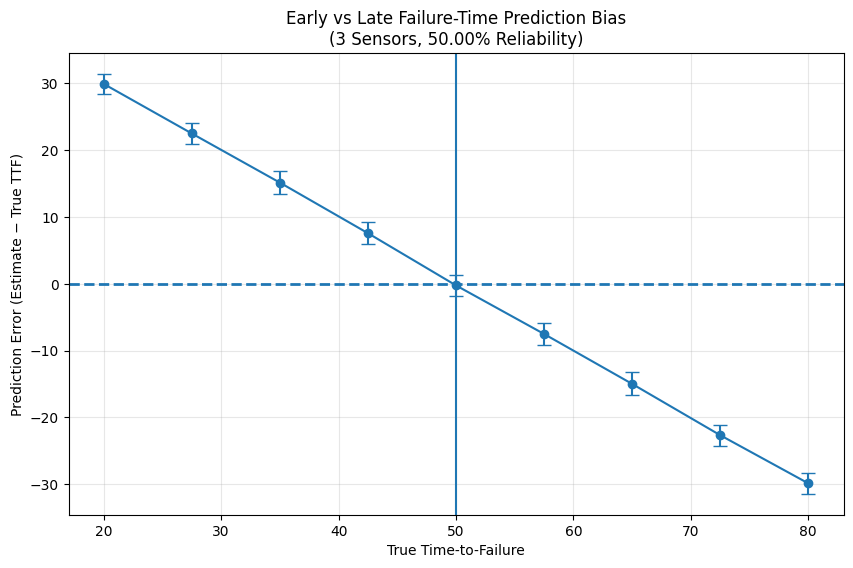

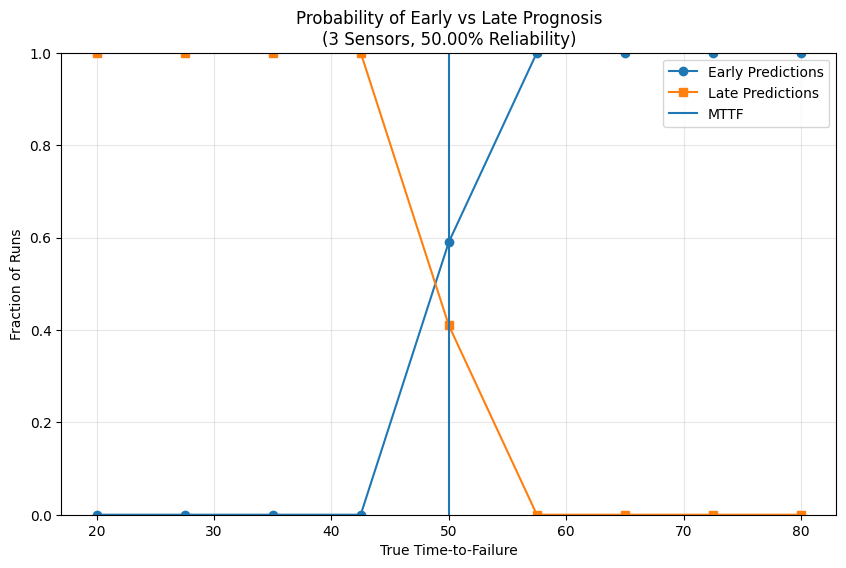

In [14]:
# Monte Carlo study: early vs late prediction bias vs true TTF
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Fixed configuration
# -----------------------------
N_SENSORS = 5
SENSOR_RELIABILITY = 0.5
N_MC = 200
N_PARTICLES = 150

TTF_VALUES = np.linspace(20, 80, 9)
MTTF = np.mean(TTF_VALUES)
t_array = np.arange(0, 120, 2)

# -----------------------------
# Models
# -----------------------------
class DiagnosisSensor:
    def __init__(self, sensor_reliability: float):
        self.sensor_reliability = sensor_reliability

    def generate_evidence(self, true_state: int) -> int:
        if np.random.rand() < self.sensor_reliability:
            return true_state
        return 1 - true_state


class SimpleTTFParticleFilter:
    def __init__(
        self,
        true_ttf,
        sensors,
        mttf,
        n_particles=150,
        prior_sigma_frac=0.4
    ):
        self.true_ttf = true_ttf
        self.sensors = sensors
        self.n = n_particles

        sigma = prior_sigma_frac * mttf
        self.particles = np.clip(
            np.random.normal(mttf, sigma, self.n),
            0.1,
            None
        )
        self.weights = np.ones(self.n) / self.n

    def step(self, t):
        true_state = 1 if t < self.true_ttf else 0
        z = [s.generate_evidence(true_state) for s in self.sensors]

        for i in range(self.n):
            predicted_state = 1 if t < self.particles[i] else 0
            for obs, s in zip(z, self.sensors):
                self.weights[i] *= (
                    s.sensor_reliability if obs == predicted_state
                    else (1 - s.sensor_reliability)
                )

        self.weights += 1e-12
        self.weights /= np.sum(self.weights)

        n_eff = 1.0 / np.sum(self.weights ** 2)
        if n_eff < 0.5 * self.n:
            idx = np.random.choice(self.n, self.n, p=self.weights)
            self.particles = self.particles[idx]
            self.weights[:] = 1.0 / self.n

    def estimate(self):
        return np.sum(self.weights * self.particles)


# -----------------------------
# Monte Carlo experiment
# -----------------------------
mean_error = []
std_error = []
early_frac = []
late_frac = []

for true_ttf in TTF_VALUES:
    errors = []

    for _ in range(N_MC):
        sensors = [DiagnosisSensor(SENSOR_RELIABILITY) for _ in range(N_SENSORS)]
        pf = SimpleTTFParticleFilter(
            true_ttf=true_ttf,
            sensors=sensors,
            mttf=MTTF,
            n_particles=150
        )
        for t in t_array:
            pf.step(t)

        est = pf.estimate()
        errors.append(est - true_ttf)

    errors = np.array(errors)
    mean_error.append(np.mean(errors))
    std_error.append(np.std(errors))
    early_frac.append(np.mean(errors < 0))
    late_frac.append(np.mean(errors > 0))

# -----------------------------
# Plot bias behavior
# -----------------------------
plt.figure(figsize=(10, 6))
plt.axhline(0, linestyle="--", linewidth=2)
plt.errorbar(
    TTF_VALUES,
    mean_error,
    yerr=std_error,
    marker="o",
    capsize=5
)
plt.axvline(MTTF, label="MTTF")
plt.xlabel("True Time-to-Failure")
plt.ylabel("Prediction Error (Estimate − True TTF)")
plt.title(f"Early vs Late Failure-Time Prediction Bias\n(3 Sensors, {SENSOR_RELIABILITY:.2%} Reliability)")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# Plot early vs late probability
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(TTF_VALUES, early_frac, marker="o", label="Early Predictions")
plt.plot(TTF_VALUES, late_frac, marker="s", label="Late Predictions")
plt.axvline(MTTF, label="MTTF")
plt.xlabel("True Time-to-Failure")
plt.ylabel("Fraction of Runs")
plt.title(f"Probability of Early vs Late Prognosis\n(3 Sensors, {SENSOR_RELIABILITY:.2%} Reliability)")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Checking if PF RUL estimate will be different for different components or if it only varies with time 

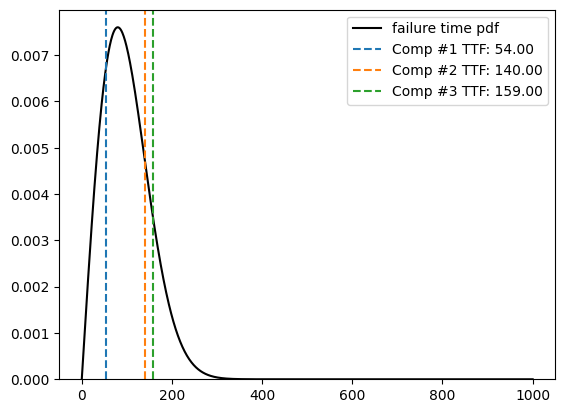

In [ ]:
from component_objects.component_weibull import WeibullComponent
from sensor_objects.diagnostic_sensors.binary_diagnostic_sensor import BinaryDiagnosticSensor
from sensor_objects.prognostic_sensors.PF_prognostic_sensor import PF_PrognosticSensor
from sensed_objects.sensed_comp import BaseSensedComponent

import numpy as np
import matplotlib.pyplot as plt

# fix random seed
random_seed = 74
np.random.seed(random_seed)

# simulation parameters
comp_MTTF = 100
shape_parameter= 2
num_comps = 3                           # number of failure instances from distribution
num_diagnostic_sensors = 3              # number of diagnostic sensors used as evidence for prognosis
diagnostic_sensor_reliability = 1.00    # starting with 100% sensing accuracy

# initialize n components with the same weibull distribution
comps = [WeibullComponent(f"Comp #{i+1}", MTTF = comp_MTTF, MTTR= 10, shape=shape_parameter) for i in range(3)]

# plot the component faiure distribution and highlight the n comp failure instances
t_array = np.linspace(0, 1000, 1000)
plt.figure()
ax = comps[0].plot_failure_pdf(t_array)
comps[1].plot_time_to_fail()
comps[2].plot_time_to_fail()
plt.show()

# initialize diagnosis sensors for each component which all have the same sensing reliability
diagnostic_sensors = [None for _ in range(num_comps)]
for i in range(num_comps):
    diagnostic_sensors[i] = [BinaryDiagnosticSensor(diagnostic_sensor_reliability) for _ in range(num_diagnostic_sensors)]

# initialize one prognosis sensor per component
prognostic_sensors = [PF_PrognosticSensor()]

# pair diagnostic sensors and one prognosis sensor to the components
sensed_comps = [BaseSensedComponent(comp[i], diagnostic_sensors[i], prognostic_sensors[i]) for i in range(len(comps))]